### Restaurant count per census tract

Census tracts generally have about 4000 people but can vary from 1000-8000.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load chinese restaurants by locale type

restaurants = pd.read_csv('restaurants_by_tract.csv')
print(restaurants.shape)
restaurants.head()

(85381, 15)


,Join_Count,GEOID,NAME,population,chinese,chinese_pct,rest_per_ch,rest_per_100ch,whiteE,LOCALE,STATEFP,state,LOC_NAME,Shape_Length,Shape_Area
0,1,1089003100,Census Tract 31; Madison County; Alabama,3699.0,0,0.00000,0.000000,0.000000,2962.0,12.0,1.0,Alabama,Midsize City,0.084580,0.000427
1,0,1089000501,Census Tract 5.01; Madison County; Alabama,1909.0,0,0.00000,0.000000,0.000000,249.0,12.0,1.0,Alabama,Midsize City,0.091622,0.000277
2,3,1089011021,Census Tract 110.21; Madison County; Alabama,5297.0,36,0.67963,0.083333,8.333334,3001.0,21.0,1.0,Alabama,Large Suburban,0.154113,0.001117
3,2,1095031200,Census Tract 312; Marshall County; Alabama,5727.0,0,0.00000,0.000000,0.000000,4243.0,32.0,1.0,Alabama,Distant Town,0.221217,0.002843
4,1,1073012401,Census Tract 124.01; Jefferson County; Alabama,3660.0,0,0.00000,0.000000,0.000000,123.0,21.0,1.0,Alabama,Large Suburban,0.106357,0.000460


In [3]:
# remove Puerto Rico for now
restaurants = restaurants[restaurants['state'] != 'Puerto Rico']
restaurants.shape

(84452, 15)

In [7]:
# number of census tracts per state where LOC_NAME is Fringe Town, Distant Town, or Remote Town
small_town_tracts = restaurants[restaurants['LOC_NAME'].isin(['Fringe Town', 'Distant Town', 'Remote Town'])]
small_town_tracts_by_state = small_town_tracts.groupby('state').size().sort_values(ascending=False)
small_town_tracts_by_state

state
Texas             282
California        267
Pennsylvania      236
New York          194
Ohio              191
North Carolina    165
Illinois          149
Michigan          138
Indiana           118
Wisconsin         117
Missouri          111
Minnesota         110
Mississippi       107
Iowa              101
Oklahoma          100
Kentucky           95
Washington         92
Kansas             90
Georgia            88
Tennessee          83
Oregon             82
Virginia           77
Louisiana          69
Florida            62
New Mexico         62
South Carolina     59
Arizona            58
Arkansas           56
Colorado           53
Alabama            51
Maryland           45
New Jersey         41
Delaware           38
Nebraska           36
Utah               33
Connecticut        33
Nevada             32
Massachusetts      30
Hawaii             29
West Virginia      28
Montana            27
South Dakota       25
Idaho              22
Wyoming            19
New Hampshire      18
Verm

In [21]:
# count number of restaurants (Join_Count) per state where LOC_NAME is Fringe Town, Distant Town, or Remote Town
small_town_restaurants_by_state = small_town_tracts.groupby('state')['Join_Count'].sum().sort_values(ascending=False)
small_town_restaurants_by_state


state
California        209
Texas             205
Pennsylvania      199
Ohio              162
New York          154
North Carolina    145
Missouri          123
Illinois          117
Oregon            111
Wisconsin          95
Indiana            94
Michigan           91
Georgia            89
Iowa               86
Tennessee          78
Minnesota          77
Oklahoma           75
Kansas             71
South Carolina     70
Mississippi        68
Kentucky           67
Washington         64
Florida            62
Virginia           62
New Jersey         50
Arkansas           43
Alabama            42
Louisiana          42
Maryland           37
New Mexico         36
Colorado           33
Hawaii             32
Connecticut        32
Arizona            30
Vermont            27
Delaware           26
Maine              25
New Hampshire      23
Nebraska           21
Utah               21
Massachusetts      20
West Virginia      19
Montana            18
South Dakota       17
Nevada             15
Idah

In [22]:
# normalize small_town_restaurants_by_state by small_town_tracts_by_state
small_town_restaurants_by_state = small_town_restaurants_by_state / small_town_tracts_by_state
small_town_restaurants_by_state.sort_values(ascending=False)

state
Rhode Island      1.666667
Vermont           1.588235
Maine             1.562500
Oregon            1.353659
New Hampshire     1.277778
New Jersey        1.219512
South Carolina    1.186441
Missouri          1.108108
Hawaii            1.103448
Georgia           1.011364
Florida           1.000000
Alaska            1.000000
North Dakota      1.000000
Connecticut       0.969697
Tennessee         0.939759
North Carolina    0.878788
Iowa              0.851485
Ohio              0.848168
Pennsylvania      0.843220
Alabama           0.823529
Maryland          0.822222
Wisconsin         0.811966
Virginia          0.805195
Indiana           0.796610
New York          0.793814
Kansas            0.788889
Illinois          0.785235
California        0.782772
Arkansas          0.767857
Oklahoma          0.750000
Wyoming           0.736842
Texas             0.726950
Kentucky          0.705263
Minnesota         0.700000
Washington        0.695652
Delaware          0.684211
Idaho             0.68

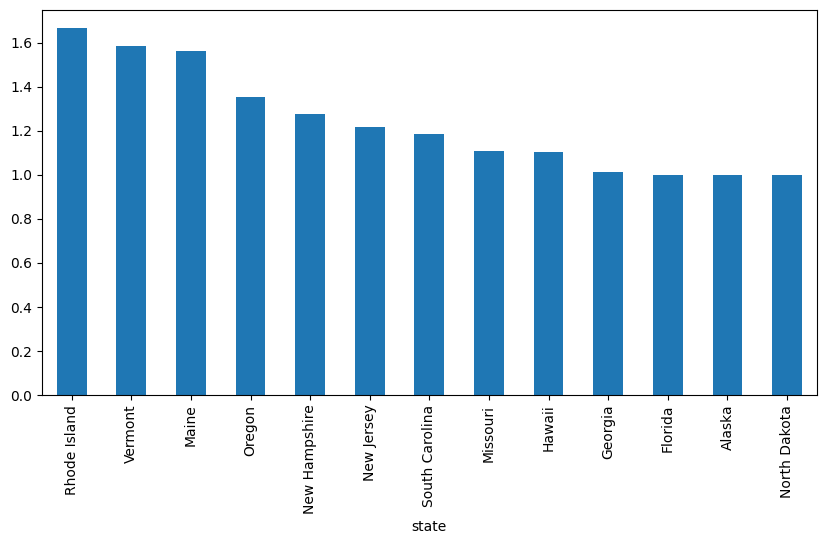

In [27]:
# plot small_town_restaurants_by_state top 10
small_town_restaurants_by_state.sort_values(ascending=False).head(13).plot(kind='bar', figsize=(10, 5))
plt.show()

In [33]:
# turn small_town_restaurants_by_state.sort_values(ascending=False).head(13) into a dataframe
small_town_restaurants_by_state_df = small_town_restaurants_by_state.sort_values(ascending=False).head(13).to_frame()
small_town_restaurants_by_state_df


,0
state,
Rhode Island,1.666667
Vermont,1.588235
Maine,1.562500
Oregon,1.353659
New Hampshire,1.277778
New Jersey,1.219512
South Carolina,1.186441
Missouri,1.108108
Hawaii,1.103448


In [31]:
# count the population numbers per state where LOC_NAME is Fringe Town, Distant Town, or Remote Town
small_town_population_by_state = small_town_tracts.groupby('state')['population'].sum().sort_values(ascending=False)
small_town_population_by_state

state
California        1158349.0
Texas             1131836.0
Pennsylvania       765829.0
Ohio               720985.0
North Carolina     615508.0
New York           611515.0
Illinois           522347.0
Michigan           484352.0
Wisconsin          480251.0
Indiana            467627.0
Minnesota          441827.0
Missouri           436300.0
Iowa               376524.0
Oregon             369240.0
Oklahoma           359367.0
Mississippi        348865.0
Tennessee          343220.0
Georgia            341079.0
Washington         340652.0
Kansas             328281.0
Kentucky           322862.0
Florida            276103.0
Virginia           262074.0
Arizona            226222.0
New Mexico         218678.0
South Carolina     217071.0
Louisiana          209996.0
Colorado           203296.0
Arkansas           193183.0
Maryland           183717.0
Alabama            179216.0
New Jersey         157291.0
Nebraska           146036.0
Utah               136335.0
Delaware           119835.0
Idaho         

In [32]:
# count number of chinese people ('chinese') per state where LOC_NAME is Fringe Town, Distant Town, or Remote Town
chinese_by_state = small_town_tracts.groupby('state')['chinese'].sum().sort_values(ascending=False)
chinese_by_state


state
Hawaii            11781
California         4022
Washington         2372
New York           2040
Ohio               1731
Pennsylvania       1698
Maryland           1359
Oregon             1227
Oklahoma            999
Texas               803
New Hampshire       795
New Jersey          723
Missouri            693
Illinois            692
North Carolina      687
Mississippi         681
Wisconsin           592
Virginia            568
Michigan            535
Colorado            487
Florida             402
Kansas              379
Idaho               378
Minnesota           376
Utah                362
Iowa                351
Arizona             348
Georgia             321
Tennessee           314
Nevada              313
South Carolina      310
Maine               297
Alabama             296
Delaware            295
Wyoming             282
South Dakota        274
Alaska              261
Rhode Island        240
Indiana             215
Nebraska            208
Massachusetts       199
Louisiana 

In [40]:
# join data from small_town_population_by_state and chinese_by_state to small_town_restaurants_by_state_df
small_town_restaurants_by_state_df = small_town_restaurants_by_state_df.join(small_town_population_by_state, on='state')
small_town_restaurants_by_state_df = small_town_restaurants_by_state_df.join(chinese_by_state, on='state')
small_town_restaurants_by_state_df

ValueError: columns overlap but no suffix specified: Index(['population'], dtype='object')

In [41]:
# change 'population' data type to integer
small_town_restaurants_by_state_df['population'] = small_town_restaurants_by_state_df['population'].astype(int)
small_town_restaurants_by_state_df['chinese'] = small_town_restaurants_by_state_df['chinese'].astype(int)
small_town_restaurants_by_state_df


,state,restaurants_per_tract,population,chinese
0,Alabama,0.823529,179216,296
1,Alaska,1.000000,49486,261
2,Arizona,0.517241,226222,348
3,Arkansas,0.767857,193183,124
4,California,0.782772,1158349,4022
5,Colorado,0.622642,203296,487
6,Connecticut,0.969697,0,0
7,Delaware,0.684211,119835,295
8,Florida,1.000000,276103,402
9,Georgia,1.011364,341079,321


In [42]:
# restaurants per tract (already the ratio) with a real column name
restaurants_per_tract = (
    small_town_restaurants_by_state
    .reset_index(name='restaurants_per_tract')
)

# add population and chinese totals for those tracts
pop_chinese = (
    small_town_tracts
    .groupby('state')[['population', 'chinese']]
    .sum()
    .reset_index()
)

In [43]:
# combine and save
small_town_restaurants_by_state_df = (
    restaurants_per_tract
    .merge(pop_chinese, on='state')
)
small_town_restaurants_by_state_df.to_csv(
    'small_town_restaurants_by_state.csv',
    index=False
)